In [ ]:
import numpy
import pandas

import matplotlib.pyplot as pyplot
import seaborn

In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [2]:
rama = pandas.read_csv("rama_2019.csv")
rama.head()

,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2
0,2019-01-01,0.642419,12.617143,22.363946,35.441905,38.940387,93.458586,63.278607,4.616041
1,2019-01-02,0.533982,18.812081,29.930827,49.379195,23.565789,63.889813,33.844221,7.147321
2,2019-01-03,0.715211,33.603041,38.135542,72.822635,24.922164,65.099404,27.566586,4.555878
3,2019-01-04,0.656344,28.825127,35.659542,65.322581,31.628838,66.979879,30.995074,3.610370
4,2019-01-05,0.547734,18.575552,32.806354,52.078098,36.803170,69.781676,35.745843,5.655977


In [36]:
X = pandas.DataFrame({
    "x1": rama["O3"],
    "x2": rama["PM10"],
})

X_scaled = StandardScaler().fit_transform(X)

X_scaled[:5]

array([[ 0.81636799,  3.20678747],
       [-0.80422671,  1.3591675 ],
       [-0.66125499,  1.4347494 ],
       [ 0.04567743,  1.55225188],
       [ 0.59108973,  1.72732362]])

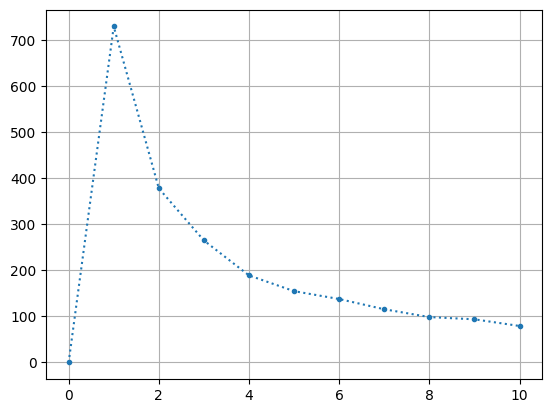

In [37]:
inertias = numpy.zeros(11)

for k in range(1, 11):
    clu = KMeans(n_clusters=k)
    clu.fit(X_scaled)
    inertias[k] = clu.inertia_

pandas.Series(inertias).plot(marker=".", linestyle=":")
pyplot.grid()
pyplot.show()

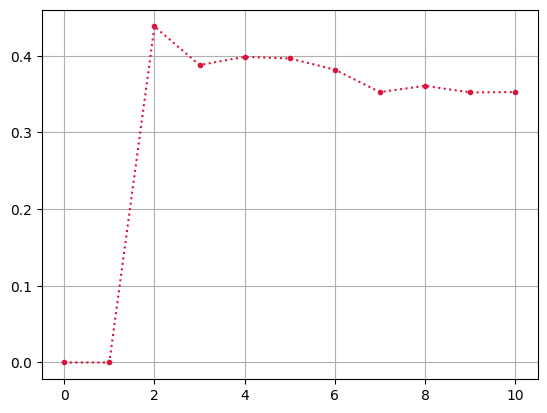

In [38]:
scores = numpy.zeros(11)

for k in range(2, 11):
    clu = KMeans(n_clusters=k, random_state=123)
    y_pred = clu.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, y_pred)
    scores[k] = score

pandas.Series(scores).plot(marker=".", linestyle=":", color="crimson")
pyplot.grid()
pyplot.show()

In [39]:
clu2 = KMeans(n_clusters=2, random_state=123)
y_pred = clu2.fit_predict(X_scaled)

rama["clu"] = y_pred

rama.head()

,fecha,CO,NO,NO2,NOX,O3,PM10,PM25,SO2,clu
0,2019-01-01,0.642419,12.617143,22.363946,35.441905,38.940387,93.458586,63.278607,4.616041,1
1,2019-01-02,0.533982,18.812081,29.930827,49.379195,23.565789,63.889813,33.844221,7.147321,1
2,2019-01-03,0.715211,33.603041,38.135542,72.822635,24.922164,65.099404,27.566586,4.555878,1
3,2019-01-04,0.656344,28.825127,35.659542,65.322581,31.628838,66.979879,30.995074,3.610370,1
4,2019-01-05,0.547734,18.575552,32.806354,52.078098,36.803170,69.781676,35.745843,5.655977,1


<Axes: xlabel='O3', ylabel='PM10'>

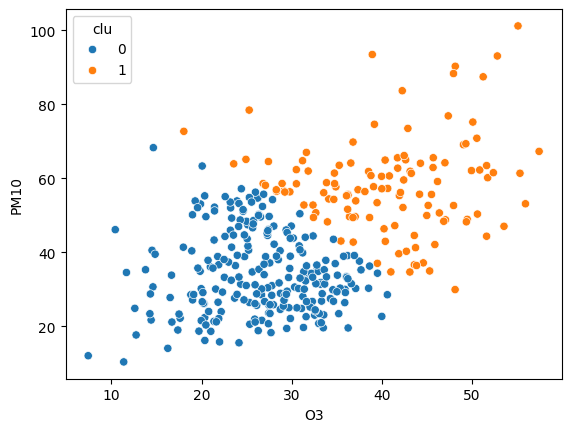

In [41]:
seaborn.scatterplot(rama, x="O3", y="PM10", hue="clu")

In [42]:
rama["clu"].value_counts()

clu
0    244
1    121
Name: count, dtype: int64

In [43]:
rama["clu"].value_counts(normalize=True)

clu
0    0.668493
1    0.331507
Name: proportion, dtype: float64

<Axes: xlabel='fecha', ylabel='clu'>

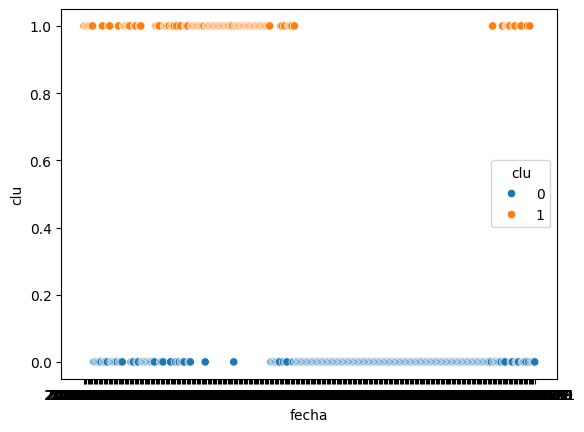

In [45]:
rama.index = pandas.date_range(start="2019-01-01", end="2019-12-31", freq="D")

rama["Fecha"] = rama.index

seaborn.scatterplot(rama, x="fecha", y="clu", hue="clu")